# RAG from scratch, on my own docs

No API keys, no vector database, no framework. A local embedding model, some numpy,
and ~14,000 words of README and CLAUDE.md files pulled out of my own repos.

The corpus matters: I wrote all of it, so I can tell whether a retrieval is right
just by reading it. That is the hardest part of evaluating a real RAG system and it
is usually missing from tutorials that search Wikipedia.

**The whole idea in one line:** the model can't see your documents, so find the few
paragraphs most likely to answer the question and paste them into the prompt.
Everything below is about *find*.

---
## 0. Attention is already retrieval

Worth starting here because it makes RAG feel less like a new trick. A transformer's
attention layer scores a query against every key, softmaxes the scores into weights,
and returns a weighted blend of the values.

In [1]:
import numpy as np

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

# Four "tokens". Pretend an encoder produced these 3-d vectors; the labels are
# just so we can read the result.
labels = ["postgres", "database", "react", "flyer"]
K = np.array([[1.0, 0.0, 0.0],
              [0.9, 0.1, 0.0],
              [0.0, 1.0, 0.0],
              [0.0, 0.0, 1.0]])
V = np.array([[10.0, 0.0], [9.0, 1.0], [0.0, 10.0], [-5.0, -5.0]])

q = np.array([1.0, 0.0, 0.0])          # asking about something postgres-shaped
weights = softmax((K @ q) * 4)          # *4 sharpens it; that's the temperature knob

for label, w in zip(labels, weights):
    print(f"{label:>10}  {w:.3f}")
print("\nblended value:", (weights[:, None] * V).sum(0).round(2))

  postgres  0.586
  database  0.393
     react  0.011
     flyer  0.011

blended value: [9.34 0.45]


That is `softmax(QKᵀ)V` with one query and no batch dimension. Attention **retrieves
from the context window** using soft weights over everything present.

RAG is the same operation with two changes: the store is a corpus that does not fit
in the context window, and the weights are hard — top-k, keep 5, drop the rest. Same
dot products, different store. That framing is why "just use a longer context window"
and "use RAG" are answers to the same question, and why the tradeoff is cost and
latency rather than capability.

---
## 1. Chunking

Documents get cut into pieces, and the piece is what gets retrieved. This is the
least glamorous part of RAG and the one that most often decides whether it works.

Cut too small and a chunk loses the context that made it meaningful. Cut too large
and the embedding averages several topics into a vector that is close to nothing.
I split on markdown headings first, because a heading is an author's own statement
about where one idea ends, then hard-wrap anything still too long.

In [2]:
import re, pathlib
from collections import Counter

CORPUS = pathlib.Path("corpus")

def split_sections(text):
    # Split before a heading, so each piece keeps its own heading as a title.
    return [p.strip() for p in re.split(r"\n(?=#{1,3} )", text) if p.strip()]

def window(section, max_chars, overlap):
    # Overlap so a fact sitting on a cut line survives in at least one chunk whole.
    if len(section) <= max_chars:
        return [section]
    out, start = [], 0
    while start < len(section):
        out.append(section[start:start + max_chars])
        start += max_chars - overlap
    return out

def build_chunks(max_chars=900, overlap=150):
    chunks = []
    for path in sorted(CORPUS.glob("*.md")):
        for section in split_sections(path.read_text()):
            for piece in window(section, max_chars, overlap):
                chunks.append({"repo": path.name.split("__")[0],
                               "file": path.name,
                               "text": piece})
    return chunks

chunks = build_chunks()
print(f"{len(chunks)} chunks from {len(list(CORPUS.glob('*.md')))} files")
print(f"median length: {int(np.median([len(c['text']) for c in chunks]))} chars\n")
sample = next(c for c in chunks if c["text"].startswith("## Non-negotiables"))
print("---", sample["file"], "---")
print(sample["text"][:420])

248 chunks from 14 files
median length: 357 chars

--- secondhandplastic__CLAUDE.md ---
## Non-negotiables

These are promises made to users in `SECURITY.md`. Treat a change that breaks one as
a bug, not a tradeoff:

1. **A user's email is never rendered.** Not in a page, an API response, or a log.
   The public label is `display_name`. `tests/test_privacy.py` enforces this.
2. **Exact coordinates are never stored.** `app/geo.fuzz` jitters before write; the
   browser's precise value is dropped.
3. **Up


---
## 2. Embedding: what the vectors actually look like

`all-MiniLM-L6-v2` is a 6-layer BERT with 22M parameters. It runs on a laptop CPU in
seconds and downloads once (~90 MB). The vector for a chunk is the mean of the final
layer's token vectors — the same pooled representation you'd take off any encoder —
squashed to 384 dimensions and normalized to unit length.

Normalizing matters for a practical reason: once every vector has length 1, the dot
product *is* the cosine similarity, so the entire search becomes one matrix multiply.

In [3]:
import logging
from sentence_transformers import SentenceTransformer

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def embed(texts):
    return encoder.encode(texts, normalize_embeddings=True, batch_size=64,
                          show_progress_bar=False)

E = embed([c["text"] for c in chunks])
print("embedding matrix:", E.shape, "  ->", E.shape[0], "chunks x", E.shape[1], "dims")
print("every row is unit length:", np.allclose(np.linalg.norm(E, axis=1), 1.0))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding matrix: (248, 384)   -> 248 chunks x 384 dims
every row is unit length: True


### Is there structure in there?

If embeddings are doing their job, chunks from the same project should land near each
other without anyone telling the model which project they came from. Projecting 384
dimensions down to 2 with PCA throws away most of the information, so treat clumping
as encouraging rather than as proof.

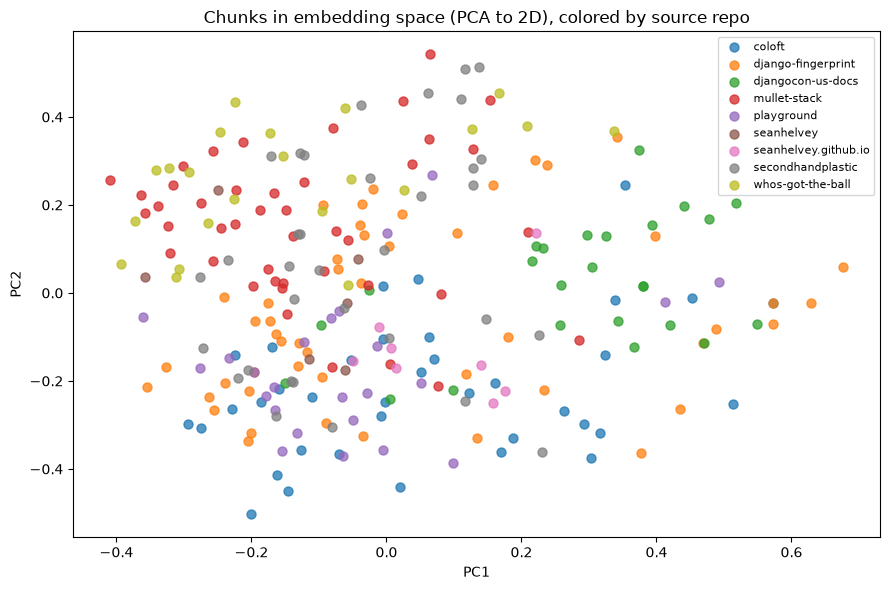

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

xy = PCA(n_components=2, random_state=0).fit_transform(E)
repos = sorted({c["repo"] for c in chunks})
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(9, 6))
for i, repo in enumerate(repos):
    m = np.array([c["repo"] == repo for c in chunks])
    ax.scatter(xy[m, 0], xy[m, 1], s=42, alpha=0.75, color=cmap(i % 10), label=repo)
ax.set_title("Chunks in embedding space (PCA to 2D), colored by source repo")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.show()

The interesting part is where the clusters *overlap*. Anything about running a dev
server or connecting to a database sits in the same neighbourhood no matter which
repo it came from — which is exactly the failure mode retrieval has to survive later.

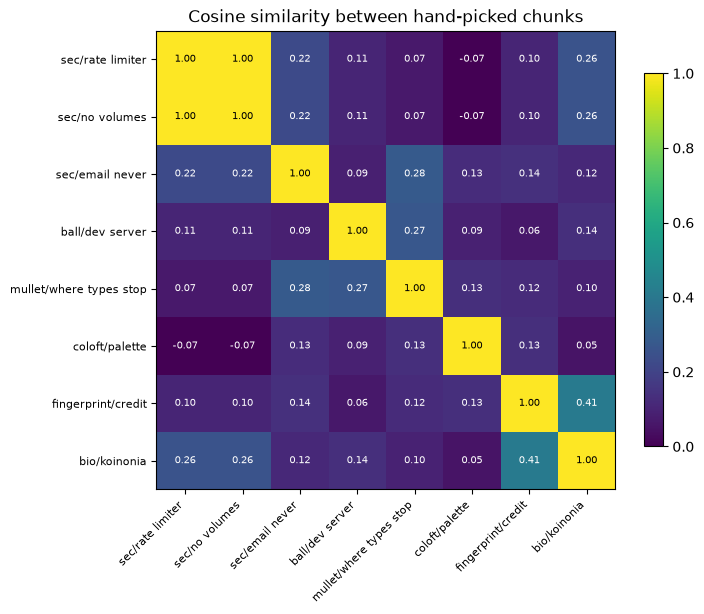

In [5]:
# Pick a few chunks by hand so the similarity matrix is readable.
def find(marker):
    return next(i for i, c in enumerate(chunks) if marker in c["text"])

picks = [
    ("sec/rate limiter", find("ratelimit.py")),
    ("sec/no volumes",   find("No persistent volumes")),
    ("sec/email never",  find("never rendered")),
    ("ball/dev server",  find("hot module reload")),
    ("mullet/where types stop", find("where the types stop")),
    ("coloft/palette",   find("Color Palette")),
    ("fingerprint/credit", find("Thibaud")),
    ("bio/koinonia",     find("Koinonia")),
]
names = [n for n, _ in picks]
S = E[[i for _, i in picks]] @ E[[i for _, i in picks]].T

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(S, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for a in range(len(names)):
    for b in range(len(names)):
        ax.text(b, a, f"{S[a, b]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if S[a, b] < 0.6 else "black")
ax.set_title("Cosine similarity between hand-picked chunks")
fig.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

Two things to notice, and both are worth saying out loud:

- The two infrastructure chunks from the same project score high together. Good.
- Nothing is near zero. Unrelated English prose still lands around 0.1–0.3, because
  these vectors encode "is written in English about software" alongside the topic.
  **Cosine similarity is not a probability.** A score of 0.45 means nothing on its own;
  it only means something relative to the other scores for the same query. This is why
  a fixed similarity threshold is a bad way to decide whether to answer.

---
## 3. Three ways to search

Each searcher scores every chunk. Keeping them as plain score arrays makes them easy
to compare and trivial to combine.

In [6]:
def dense_scores(query):
    q = embed([query])[0]
    return E @ q          # cosine similarity, because everything is unit length

def top_k(scores, k=5):
    return np.argsort(-scores)[:k]

`E @ q` is the entire vector search. Worth being blunt about this in an interview: a
vector database is that line plus persistence, metadata filtering, and an approximate
index (HNSW, IVF) so it stays fast when there are 100 million rows instead of 200.
At this scale an exact scan is *faster* than any index, and approximate search would
only cost recall. Reaching for Pinecone here would be the wrong call.

Now the other half. BM25 is keyword search — TF-IDF with two corrections that matter:
term frequency saturates (the 20th "postgres" adds almost nothing over the 3rd), and
long documents get penalized so they can't win by sheer surface area.

In [7]:
import math

def tokenize(s):
    return re.findall(r"[a-z0-9]+", s.lower())

def index_bm25(chunks):
    # Every statistic here depends on how the corpus was chunked, so this has to be
    # rebuilt whenever the chunking changes (see the sweep in section 6).
    global docs, N, avgdl, tf, df, idf
    docs  = [tokenize(c["text"]) for c in chunks]
    N     = len(docs)
    avgdl = sum(len(d) for d in docs) / N
    tf    = [Counter(d) for d in docs]
    df    = Counter(t for d in docs for t in set(d))
    idf   = {t: math.log(1 + (N - n + 0.5) / (n + 0.5)) for t, n in df.items()}

index_bm25(chunks)

def bm25_scores(query, k1=1.5, b=0.75):
    scores = np.zeros(N)
    for term in tokenize(query):
        if term not in idf:
            continue                          # a word in no document scores nothing
        for i in range(N):
            f = tf[i][term]
            if f:
                dl = len(docs[i])
                scores[i] += idf[term] * f * (k1 + 1) / (f + k1 * (1 - b + b * dl / avgdl))
    return scores

Dense and BM25 fail in opposite directions, which is the whole reason to keep both.

BM25 cannot match "wipe my local database" to `make reset` — no shared words. Dense
retrieval, meanwhile, is bad at rare exact tokens: `5433`, `JSON-LD`, a product name,
an error code, a customer ID. Those are precisely the things people search for at
work, and they are the reason pure-vector RAG disappoints in production.

Combining them by adding scores does not work — one is a cosine in [0,1], the other
is an unbounded sum of log terms. Reciprocal rank fusion sidesteps this by throwing
the scores away and using only the ranks.

In [8]:
def rrf(rankings, k=5, K=60):
    # Each list votes 1/(K + rank) for what it put where. K=60 is the value from the
    # original paper; it damps the top of each list so one confident-but-wrong
    # ranker can't run away with the fusion.
    votes = Counter()
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            votes[idx] += 1 / (K + rank)
    return [i for i, _ in votes.most_common(k)]

def hybrid(query, k=5, pool=25):
    d = top_k(dense_scores(query), pool)
    s = top_k(bm25_scores(query), pool)
    return rrf([list(d), list(s)], k=k)

In [9]:
def show(query, k=5):
    d = top_k(dense_scores(query), k)
    s = top_k(bm25_scores(query), k)
    h = hybrid(query, k)
    print(f"query: {query}\n")
    print(f"{'#':<3}{'dense':<34}{'bm25':<34}{'hybrid (RRF)':<34}")
    print("-" * 105)
    for rank in range(k):
        row = [f"{chunks[col[rank]]['file'][:26]+'#'+str(col[rank]):<34}" for col in (d, s, h)]
        print(f"{rank+1:<3}" + "".join(row))

show("wipe my local database and start over")
print()
show("what port does local postgres listen on")

query: wipe my local database and start over

#  dense                             bm25                              hybrid (RRF)                      
---------------------------------------------------------------------------------------------------------
1  secondhandplastic__CLAUDE.#194    whos-got-the-ball__README.#242    secondhandplastic__CLAUDE.#194    
2  secondhandplastic__README.#208    secondhandplastic__CLAUDE.#194    whos-got-the-ball__README.#242    
3  whos-got-the-ball__README.#247    secondhandplastic__README.#211    secondhandplastic__CLAUDE.#193    
4  secondhandplastic__CLAUDE.#193    seanhelvey__README.md#189         django-fingerprint__README#68     
5  django-fingerprint__README#68     coloft__README.md#2               djangocon-us-docs__README.#108    

query: what port does local postgres listen on

#  dense                             bm25                              hybrid (RRF)                      
---------------------------------------------------------

---
## 4. Reranking

Retrieval so far has a structural limitation. The chunk embeddings were computed
*before* anyone asked a question — that is what makes search fast, since the corpus
is encoded once — but it also means the chunk vector cannot depend on the query. This
is a **bi-encoder**: two separate passes, compared by dot product.

A **cross-encoder** puts the query and the chunk into the model together, so every
layer of attention sees both and can compare them token by token. Far more accurate,
and far too slow to run over the corpus: it is one forward pass per pair, so scoring
200 chunks means 200 forward passes.

The standard resolution is the cheap-then-expensive cascade: retrieve 25 candidates
with the fast method, rerank those 25 with the slow one, keep 5.

In [10]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, idxs):
    scores = reranker.predict([(query, chunks[i]["text"]) for i in idxs])
    return [i for _, i in sorted(zip(scores, idxs), key=lambda p: -p[0])]

def hybrid_reranked(query, k=5, pool=25):
    return rerank(query, hybrid(query, k=pool, pool=pool))[:k]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

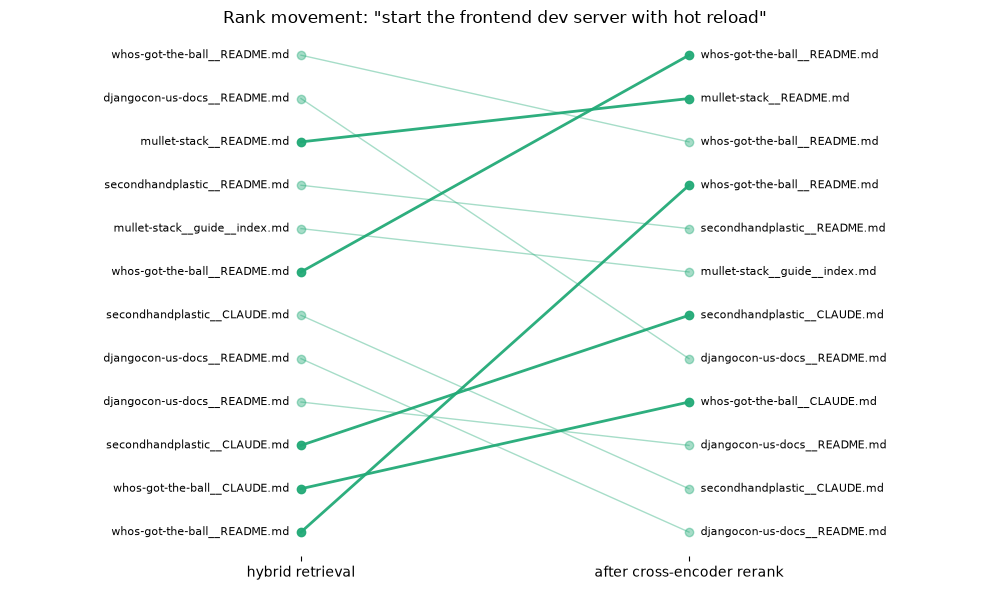

In [11]:
q = "start the frontend dev server with hot reload"
before = hybrid(q, k=12, pool=12)
after  = rerank(q, before)

fig, ax = plt.subplots(figsize=(10, 6))
for i, idx in enumerate(before):
    y0, y1 = i, after.index(idx)
    moved_up = y1 < y0
    ax.plot([0, 1], [y0, y1], marker="o",
            color="#2a7", lw=2.0 if moved_up else 1.0,
            alpha=0.95 if moved_up else 0.4)
    ax.text(-0.03, y0, chunks[idx]["file"][:32], ha="right", va="center", fontsize=8)
    ax.text(1.03, y1, chunks[idx]["file"][:32], ha="left", va="center", fontsize=8)
ax.set_xlim(-0.75, 1.75); ax.invert_yaxis(); ax.set_xticks([0, 1])
ax.set_xticklabels(["hybrid retrieval", "after cross-encoder rerank"])
ax.set_yticks([]); ax.set_title(f'Rank movement: "{q}"')
for side in ("top", "right", "left", "bottom"): ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

I picked that query because three separate repos in this corpus run a Vite dev server
on port 5173. Retrieval genuinely cannot tell them apart — there is no right answer
without knowing which project you meant. That is not a bug in the retriever, it is
missing information in the question, and the honest fix is metadata filtering (scope
the search to one repo), not a better model.

---
## 5. Does any of this actually work?

Everything above is a plausible story. None of it is evidence.

The 18 questions in `queries.json` are hand-labelled, and *how* they're labelled is
the part worth copying. Each one carries a **marker**: the exact string that has to
appear in a retrieved passage for the retrieval to count. `"make reset"`,
`"No persistent volumes"`, `"Thibaud"`. Writing them took about twenty minutes and it
is the only reason any number below means anything.

The alternative — label which *file* answers each question — is easier and useless
here. With 14 files, landing the right one in the top 5 is nearly free; I tried it
first and every method scored 1.00. Grading at the passage level asks the question
that actually matters: did the paragraph containing the answer make it into the
prompt?

- **recall@5** — did the right passage make the top 5? This is the number that
  matters, because a chunk that isn't retrieved cannot possibly be used.
- **MRR** — how high did the first correct hit land? Rewards getting it to rank 1.

In [12]:
import json

queries = json.loads(pathlib.Path("queries.json").read_text())

def evaluate(retrieve, k=5):
    hits, rr = 0, []
    for item in queries:
        got = [chunks[i]["text"] for i in retrieve(item["q"], k)]
        ranks = [r for r, text in enumerate(got, 1) if item["marker"] in text]
        hits += bool(ranks)
        rr.append(1 / ranks[0] if ranks else 0.0)
    return hits / len(queries), float(np.mean(rr))

methods = {
    "dense only":     lambda q, k: top_k(dense_scores(q), k),
    "BM25 only":      lambda q, k: top_k(bm25_scores(q), k),
    "hybrid (RRF)":   hybrid,
    "hybrid + rerank": hybrid_reranked,
}
results = {name: evaluate(fn) for name, fn in methods.items()}
for name, (r, m) in results.items():
    print(f"{name:<18} recall@5 {r:.2f}   MRR {m:.2f}")

dense only         recall@5 0.83   MRR 0.73
BM25 only          recall@5 0.83   MRR 0.68
hybrid (RRF)       recall@5 1.00   MRR 0.72
hybrid + rerank    recall@5 1.00   MRR 0.91


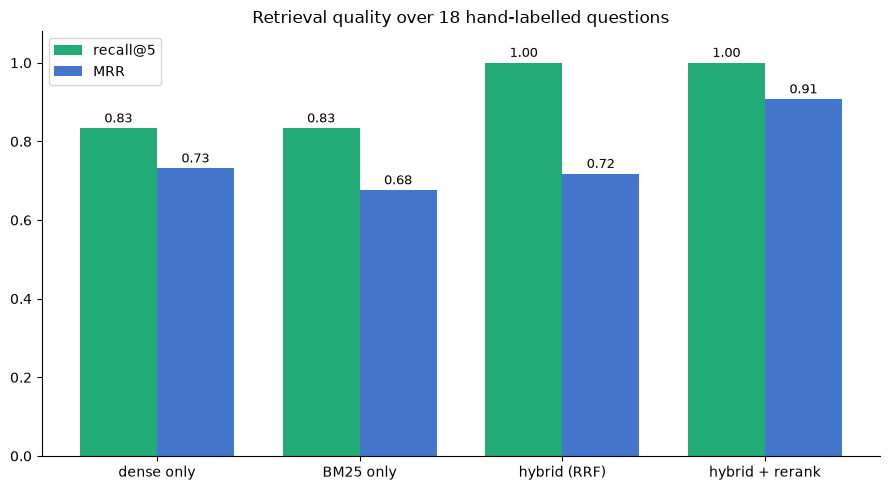

In [13]:
names = list(results)
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.19, [results[n][0] for n in names], 0.38, label="recall@5", color="#2a7")
ax.bar(x + 0.19, [results[n][1] for n in names], 0.38, label="MRR", color="#47c")
for i, n in enumerate(names):
    ax.text(i - 0.19, results[n][0] + .015, f"{results[n][0]:.2f}", ha="center", fontsize=9)
    ax.text(i + 0.19, results[n][1] + .015, f"{results[n][1]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1.08)
ax.set_title(f"Retrieval quality over {len(queries)} hand-labelled questions")
ax.legend(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

Three things to read off that chart:

1. **Dense and BM25 tie at 0.83, and fail on different questions.** That is the whole
   argument for hybrid search. If they failed on the *same* questions, fusing them
   would buy nothing — the failure list below is the evidence, not the tie.
2. **RRF fixes recall but not ranking.** Hybrid recall jumps to 1.00 while MRR barely
   moves (0.73 → 0.72). Fusion is good at getting the right passage *somewhere* into
   the top 5. It has no idea which of the five is best.
3. **The cross-encoder is what fixes ranking.** MRR 0.72 → 0.91 over the same
   candidates, retrieving nothing new — pure reordering. That sounds cosmetic until
   you remember the prompt has room for 3 chunks, not 25.

So the two stages do genuinely different jobs, and "should I add a reranker" and
"should I add BM25" are not competing answers to the same question.

In [14]:
# Where does each method actually break? This is the useful half of an eval.
for item in queries:
    row = {}
    for name, fn in methods.items():
        got = [chunks[i]["text"] for i in fn(item["q"], 5)]
        row[name] = any(item["marker"] in text for text in got)
    if not all(row.values()):
        missed = ", ".join(n for n, ok in row.items() if not ok)
        print(f'MISS  "{item["q"]}"\n      failed for: {missed}')
        if item["note"]:
            print(f'      note: {item["note"]}')
        print()

MISS  "how do I wipe my local database and start over?"
      failed for: BM25 only
      note: query shares almost no words with the answer



MISS  "what port does local Postgres listen on?"
      failed for: dense only
      note: lexical: a rare exact token, BM25 territory



MISS  "what does it mean for someone to have the ball?"
      failed for: BM25 only



MISS  "start the frontend dev server with hot reload"
      failed for: dense only
      note: AMBIGUOUS ON PURPOSE: three separate repos run Vite on 5173



MISS  "where do the TypeScript types stop lining up with the Python ones?"
      failed for: dense only



MISS  "what colors does the site use?"
      failed for: BM25 only
      note: 'colors' vs 'palette' is a small semantic gap BM25 cannot cross



---
## 6. The chunk size knob

One parameter, no model changes. Small chunks are precise but lose the context that
made them meaningful; large chunks blur several topics into a single vector that
sits near none of them.

Note that BM25 has to be rebuilt too — document frequency and average document
length are properties of the chunking, not of the corpus.

max_chars=200   chunks=682  dense=0.78  hybrid=0.83


max_chars=300   chunks=488  dense=0.83  hybrid=0.89


max_chars=450   chunks=361  dense=0.89  hybrid=0.94


max_chars=600   chunks=303  dense=0.83  hybrid=0.94


max_chars=900   chunks=248  dense=0.83  hybrid=1.00


max_chars=1500  chunks=207  dense=0.83  hybrid=0.94


max_chars=2500  chunks=196  dense=0.83  hybrid=0.94


max_chars=4000  chunks=192  dense=0.83  hybrid=0.94


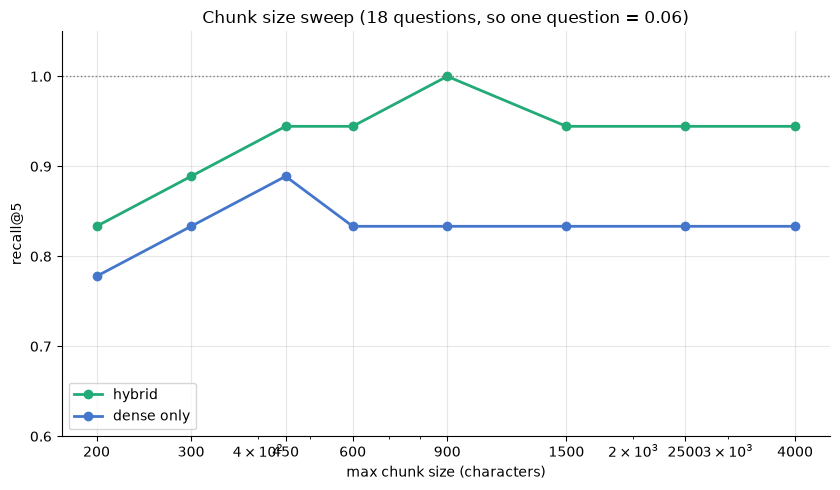

In [15]:
sizes = [200, 300, 450, 600, 900, 1500, 2500, 4000]
dense_curve, hybrid_curve = [], []

for size in sizes:
    chunks = build_chunks(max_chars=size, overlap=size // 6)
    E = embed([c["text"] for c in chunks])
    index_bm25(chunks)
    dense_curve.append(evaluate(lambda q, k: top_k(dense_scores(q), k))[0])
    hybrid_curve.append(evaluate(hybrid)[0])
    print(f"max_chars={size:<5} chunks={len(chunks):<4} "
          f"dense={dense_curve[-1]:.2f}  hybrid={hybrid_curve[-1]:.2f}")

# Put everything back to the 900-char setup the rest of the notebook assumes.
chunks = build_chunks()
E = embed([c["text"] for c in chunks])
index_bm25(chunks)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(sizes, hybrid_curve, marker="o", lw=2, color="#2a7", label="hybrid")
ax.plot(sizes, dense_curve, marker="o", lw=2, color="#47c", label="dense only")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xscale("log"); ax.set_xticks(sizes)
ax.set_xticklabels([str(s) for s in sizes])
ax.set_xlabel("max chunk size (characters)"); ax.set_ylabel("recall@5")
ax.set_ylim(0.6, 1.05)
ax.set_title(f"Chunk size sweep ({len(queries)} questions, so one question = {1/len(queries):.2f})")
ax.legend(); ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

There is a peak, and it sits around 900 characters — roughly one medium markdown
section. Both curves fall off on either side, which is the tradeoff behaving the way
the theory says it should.

**Be careful how hard you lean on that.** There are 18 questions, so one question is
worth 0.06 recall, and the gap between the peak and its neighbours is one or two
questions wide. The shape is suggestive, not significant. The honest conclusion is
"900 is a sensible default for documents like these, worth re-checking against a
bigger eval set" — not "900 is optimal."

Knowing the resolution of your own evaluation is part of the job. An eval that cannot
separate 0.94 from 1.00 also cannot referee an argument about chunk size.

---
## 7. The generation half

There is no API call in this notebook, so nothing here needs a key. That is partly
convenience and partly the point: retrieval is where nearly all the engineering lives,
and it is fully measurable without a language model in the loop. The G in RAG is one
request with the retrieved text in the prompt.

In [16]:
question = "why is the rate limiter backed by the database instead of kept in memory?"
picked   = hybrid_reranked(question, k=3)

context = "\n\n---\n\n".join(
    f"[source: {chunks[i]['file']}]\n{chunks[i]['text']}" for i in picked
)
prompt = "\n".join([
    "Answer the question using only the sources below.",
    "Cite the source filename for each claim.",
    "If the sources do not contain the answer, say so instead of guessing.",
    "",
    "SOURCES:",
    context,
    "",
    f"QUESTION: {question}",
])
print(prompt)

Answer the question using only the sources below.
Cite the source filename for each claim.
If the sources do not contain the answer, say so instead of guessing.

SOURCES:
[source: secondhandplastic__README.md]
### Why the pooler

Zero-downtime deploys run old and new instances at once, and Supabase's direct
connection allows far too few connections for that — so the app connects through the
transaction pooler on 6543. Server-side prepared statements are disabled to suit it.
Migrations are the exception: DDL through the transaction pooler is unreliable, so
`CS_MIGRATION_DATABASE_URL` should point at the direct or session connection on 5432.

Nothing may assume a single process. Most migrations must be additive-only, aside
from the `post_deploy` exception above; the app does no schema work at startup; and
`app/ratelimit.py` is Postgres-backed rather than in-memory, so limits are shared
and survive a restart.

---

[source: secondhandplastic__CLAUDE.md]
## Platform constraints that shape 

Three things in that prompt are doing real work, and each one has a failure it
prevents:

1. **"using only the sources below"** — without it the model answers from pretraining
   and you cannot tell retrieval failed.
2. **"cite the source filename"** — makes every claim checkable, and citations that
   don't match the retrieved text are the cheapest hallucination detector there is.
3. **"say so instead of guessing"** — gives the model an exit. Retrieval will
   sometimes return nothing useful, and a confident wrong answer is worse than "I
   don't know."

Sending it is `client.messages.create(model="claude-opus-5", ...)` with that string as
the user message. Nothing in this notebook changes.

**The failure worth understanding:** good retrieval does not guarantee a good answer.
The right chunk can be sitting in the prompt and the model still gets it wrong — which
is why RAG evaluation has two halves. Retrieval metrics (measured above) and
faithfulness, meaning *is every claim in the answer supported by the retrieved text*.
The second is usually scored by a second model reading answer and sources together.

---
## 8. What I left out

Deliberately, to keep this readable. Roughly in order of how much they'd change the
numbers on a corpus like this:

- **Contextual retrieval** — prefix each chunk with a sentence describing where it
  sits in its document before embedding it. Cheap, and it fixes the biggest weakness
  in section 1: a chunk cut from the middle of a file loses the context that made it
  make sense.
- **Metadata filtering** — scoping the search to one repo. Section 4 showed a query
  no retriever can resolve without it. Usually a bigger win than a better model.
- **Query rewriting** — expanding or splitting the question before searching, so
  "how do I run this" becomes something with content words in it.
- **Matryoshka embeddings** — trained so the first 64 dimensions are usable on their
  own, letting you cut memory ~6x for a small quality loss. Search cheap, rescore
  exact.
- **Late interaction (ColBERT)** — a vector per token instead of per chunk. Close to
  cross-encoder quality at closer to bi-encoder speed.
- **Multi-hop / agentic retrieval** — let the model search, read, and search again,
  for questions no single query can answer.

**The honest summary of everything above:** almost none of the work is in the vector
math. It is in cutting documents sensibly, keeping keyword search alongside semantic
search, spending an afternoon writing labelled questions, and then having numbers to
point at when someone proposes a change.